In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('standardizedrevenue1.csv')
df

,Unnamed: 0,Order_ID,Order_Date,Product_Name,Units_Sold,Unit_Price,Revenue
0,0,686800706,10/18/2014,Cosmetics,8446,437.20,3692591.20
1,1,185941302,11/7/2011,Vegetables,3018,154.06,464953.08
2,2,246222341,10/31/2016,Baby Food,1517,255.28,387259.76
3,3,161442649,4/10/2010,Cereal,3322,205.70,683335.40
4,4,645713555,8/16/2011,Fruits,9845,9.33,91853.85
...,...,...,...,...,...,...,...
995,995,534085166,4/18/2010,Snacks,6524,152.58,995431.92
996,996,590768182,8/1/2011,Baby Food,288,255.28,73520.64
997,997,524363124,5/12/2011,Vegetables,9556,154.06,1472197.36
998,998,289606320,1/25/2016,Household,9801,668.27,6549714.27


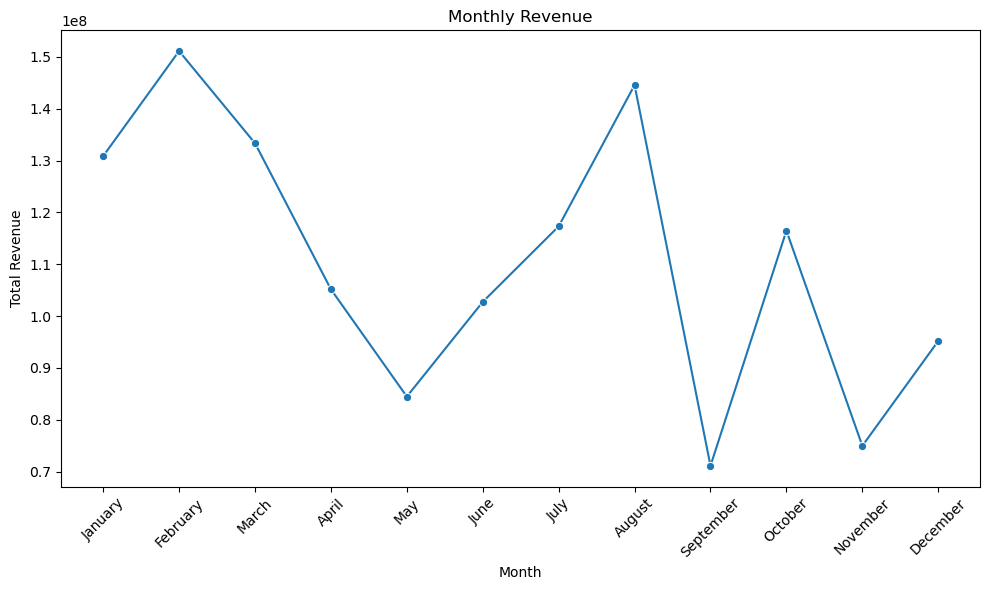

In [4]:
# LINE PLOT : REVENUE OVER TIME
# Step 1: Standardize Order_Date format
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce', infer_datetime_format=True)

# Step 2: Drop rows with invalid/missing dates
df = df.dropna(subset=['Order_Date'])

# Step 3: Extract full month names
df['Month'] = df['Order_Date'].dt.month_name()

# Step 4: Define proper month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Step 5: Group by month and sum revenue
monthly_revenue = df.groupby('Month', as_index=False)['Revenue'].sum()

# Step 6: Reorder months in calendar order
monthly_revenue['Month'] = pd.Categorical(monthly_revenue['Month'], categories=month_order, ordered=True)
monthly_revenue = monthly_revenue.sort_values('Month')

# Step 7: Plot line chart using Seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_revenue, x='Month', y='Revenue', marker='o')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()

# Step 8: Save and display the plot
plt.savefig('Reveue_Over_Time.png')
plt.show()

In [5]:
# BAR CHART: TOP PRODUCTS BY REVENUE
# Get the product revenue
df = df[df['Product_Name'] != 'Product']
df

,Unnamed: 0,Order_ID,Order_Date,Product_Name,Units_Sold,Unit_Price,Revenue,Month
0,0,686800706,2014-10-18,Cosmetics,8446,437.20,3692591.20,October
1,1,185941302,2011-11-07,Vegetables,3018,154.06,464953.08,November
2,2,246222341,2016-10-31,Baby Food,1517,255.28,387259.76,October
3,3,161442649,2010-04-10,Cereal,3322,205.70,683335.40,April
4,4,645713555,2011-08-16,Fruits,9845,9.33,91853.85,August
...,...,...,...,...,...,...,...,...
995,995,534085166,2010-04-18,Snacks,6524,152.58,995431.92,April
996,996,590768182,2011-08-01,Baby Food,288,255.28,73520.64,August
997,997,524363124,2011-05-12,Vegetables,9556,154.06,1472197.36,May
998,998,289606320,2016-01-25,Household,9801,668.27,6549714.27,January


In [6]:
product_revenue = df.groupby('Product_Name')['Revenue'].sum().reset_index()
product_revenue = product_revenue.sort_values('Revenue', ascending=False)
product_revenue

,Product_Name,Revenue
8,Office Supplies,2.894511e+08
6,Household,2.479228e+08
4,Cosmetics,1.862787e+08
7,Meat,1.720953e+08
0,Baby Food,1.114598e+08
2,Cereal,7.975997e+07
11,Vegetables,7.260478e+07
10,Snacks,6.029107e+07
3,Clothes,4.130631e+07
9,Personal Care,3.888092e+07


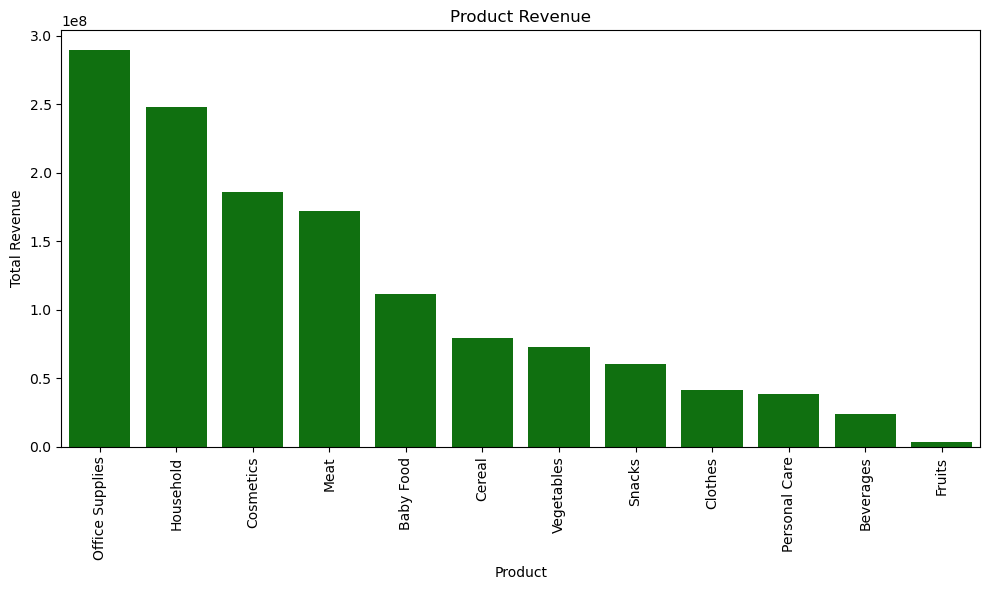

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(data=product_revenue, x='Product_Name', y='Revenue', color = 'g')
plt.title('Product Revenue')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('Product Revenue.png')

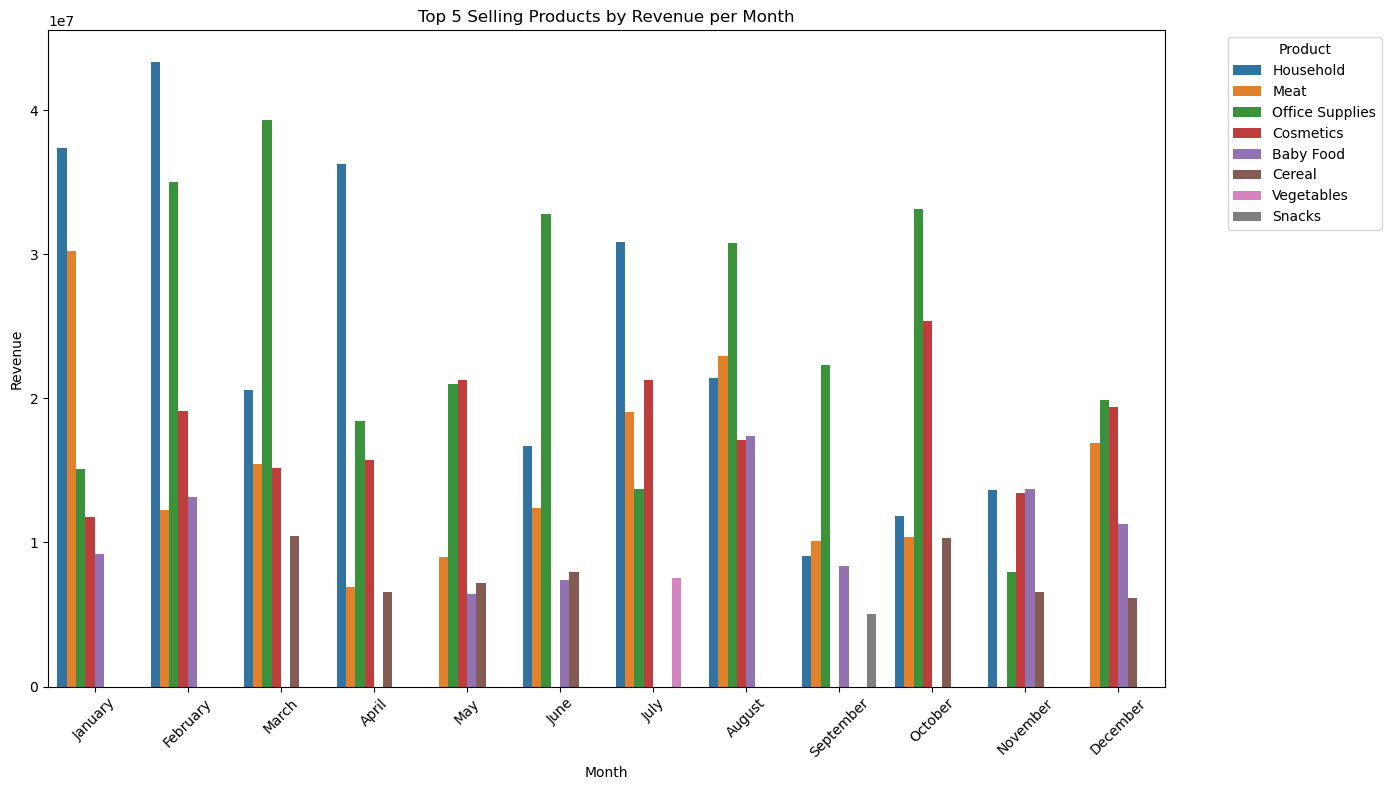

In [8]:
# BAR CHART: TOP SELLING PRODUCT BY MONTH

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Convert Order_Date and extract month
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce', infer_datetime_format=True)
df = df.dropna(subset=['Order_Date'])
df['Month'] = df['Order_Date'].dt.month_name()

# Step 2: Define correct month order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

# Step 3: Group by Month and Product to get monthly revenue
monthly_product_revenue = df.groupby(['Month', 'Product_Name'], as_index=False)['Revenue'].sum()

# Step 4: Get top 5 products per month
top5_per_month = monthly_product_revenue.sort_values(['Month', 'Revenue'], ascending=[True, False]) \
    .groupby('Month').head(5)

# Step 5: Plot
plt.figure(figsize=(14, 8))
sns.barplot(data=top5_per_month, x='Month', y='Revenue', hue='Product_Name')
plt.title('Top 5 Selling Products by Revenue per Month')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend(title='Product', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Top Products by Month.png')
plt.show()

In [9]:
# BAR PLOT: MONTHLY FOOTFALL
month_counts = df.groupby('Month').size().reset_index(name = 'Count')
month_counts

,Month,Count
0,January,94
1,February,93
2,March,89
3,April,74
4,May,76
5,June,77
6,July,89
7,August,100
8,September,70
9,October,89


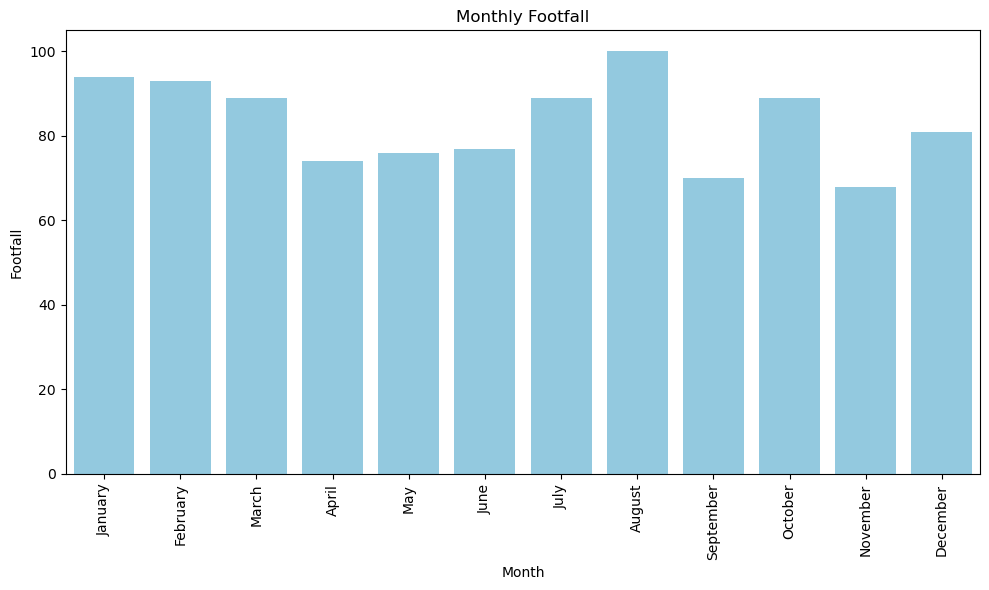

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(data=month_counts, x='Month', y='Count', color = 'skyblue')
plt.title('Monthly Footfall')
plt.xlabel('Month')
plt.ylabel('Footfall')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('Monthly Footfall.png')

In [38]:
# PIE CHART: TOP PRODUCTS BY REVENUE
revenue_product = df.groupby('Product_Name', as_index=False)['Revenue'].sum()
sort = revenue_product.sort_values(by = 'Revenue', ascending = False)
top_products = sort.head(5)
products = top_products['Product_Name'].tolist()
revenue = top_products['Revenue'].tolist()

[289451123.22, 247922823.84, 186278678.4, 172095259.35, 111459843.04]

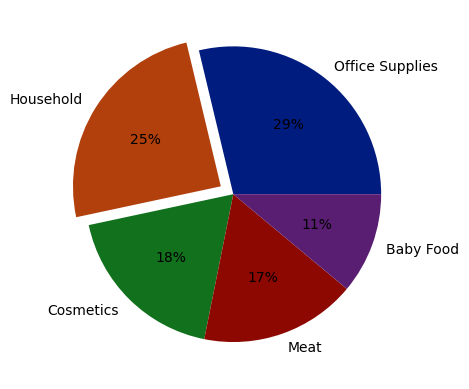

In [40]:
# PIE CHART: PRODUCTS BY REVENUE
# declaring exploding pie
explode = [0, 0.1, 0, 0, 0]

# define Seaborn color palette to use
colors = sns.color_palette('dark')

# plotting data on chart
plt.pie(revenue, labels=products, colors=colors, explode=explode, autopct='%.0f%%')
plt.savefig('ProductsbyRevenue.png')
plt.show()

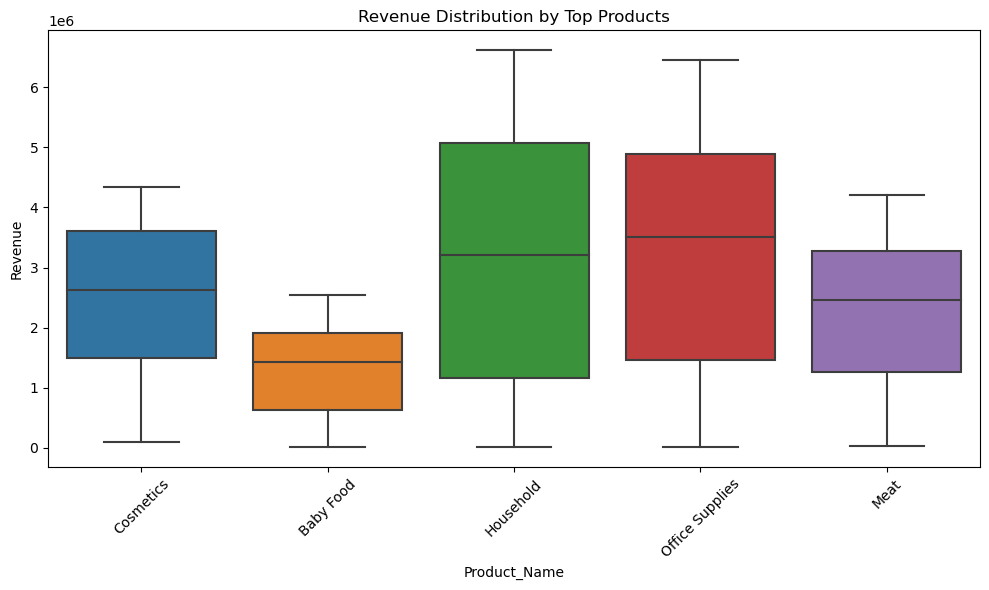

In [43]:
# BOXPLOT: REVENUE
# Clean and prepare data
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')
df['Product_Name'] = df['Product_Name'].astype(str)

# Optional: Filter top products only
top_products = df.groupby('Product_Name')['Revenue'].sum().nlargest(5).index
df_top = df[df['Product_Name'].isin(top_products)]

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_top, x='Product_Name', y='Revenue')
plt.title('Revenue Distribution by Top Products')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()